In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [ ]:
df = pd.read_csv('/content/flights.csv.zip', compression='zip')

df.head()

,Unnamed: 0,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,1740355,2015,4,21,2,EV,6049,N10575,EWR,IAD,...,2117.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1500827,2015,4,7,2,AS,81,N706AS,SEA,ANC,...,829.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,3282889,2015,7,24,5,EV,5236,N936EV,MOB,ATL,...,1539.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,652599,2015,2,13,5,UA,668,N440UA,ORD,LGA,...,915.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,3988136,2015,9,5,6,AS,615,N517AS,LAS,SEA,...,908.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872862 entries, 0 to 872861
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           872862 non-null  int64  
 1   YEAR                 872862 non-null  int64  
 2   MONTH                872862 non-null  int64  
 3   DAY                  872862 non-null  int64  
 4   DAY_OF_WEEK          872862 non-null  int64  
 5   AIRLINE              872862 non-null  object 
 6   FLIGHT_NUMBER        872862 non-null  int64  
 7   TAIL_NUMBER          870613 non-null  object 
 8   ORIGIN_AIRPORT       872862 non-null  object 
 9   DESTINATION_AIRPORT  872862 non-null  object 
 10  SCHEDULED_DEPARTURE  872862 non-null  int64  
 11  DEPARTURE_TIME       859935 non-null  float64
 12  DEPARTURE_DELAY      859935 non-null  float64
 13  TAXI_OUT             859511 non-null  float64
 14  WHEELS_OFF           859511 non-null  float64
 15  SCHEDULED_TIME   

In [ ]:
df.describe()

,Unnamed: 0,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,8.728620e+05,872862.0,872862.000000,872862.000000,872862.000000,872862.000000,872862.000000,859935.000000,859935.000000,859511.000000,...,872862.000000,858968.000000,857061.000000,872862.000000,872862.000000,159157.000000,159157.000000,159157.000000,159157.000000,159157.000000
mean,2.910368e+06,2015.0,6.525428,15.715727,3.926999,2171.662199,1328.671122,1334.217378,9.355634,16.064538,...,1492.725787,1475.577164,4.398053,0.002643,0.015459,13.435532,0.075039,19.121201,23.420805,2.888255
std,1.679954e+06,0.0,3.406028,8.782985,1.988505,1758.544806,484.320281,497.053194,37.010731,8.878921,...,507.444218,526.497275,39.191761,0.051342,0.123371,27.909399,2.111429,48.668576,42.842858,20.076678
min,0.000000e+00,2015.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-42.000000,1.000000,...,1.000000,1.000000,-81.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.454624e+06,2015.0,4.000000,8.000000,2.000000,727.000000,915.000000,919.000000,-5.000000,11.000000,...,1109.000000,1057.000000,-13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.910594e+06,2015.0,7.000000,16.000000,4.000000,1687.000000,1325.000000,1330.000000,-2.000000,14.000000,...,1520.000000,1512.000000,-5.000000,0.000000,0.000000,2.000000,0.000000,2.000000,3.000000,0.000000
75%,4.365323e+06,2015.0,9.000000,23.000000,6.000000,3228.000000,1730.000000,1740.000000,7.000000,19.000000,...,1917.000000,1916.000000,8.000000,0.000000,0.000000,18.000000,0.000000,19.000000,29.000000,0.000000
max,5.819061e+06,2015.0,12.000000,31.000000,7.000000,8442.000000,2359.000000,2400.000000,1609.000000,180.000000,...,2359.000000,2400.000000,1598.000000,1.000000,1.000000,798.000000,364.000000,1563.000000,1331.000000,1120.000000


In [ ]:
df.shape

(872862, 32)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,2249
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0


In [ ]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
CANCELLATION_REASON,98.454051
AIRLINE_DELAY,81.766075
LATE_AIRCRAFT_DELAY,81.766075
WEATHER_DELAY,81.766075
SECURITY_DELAY,81.766075
AIR_SYSTEM_DELAY,81.766075
AIR_TIME,1.810252
ELAPSED_TIME,1.810252
ARRIVAL_DELAY,1.810252
ARRIVAL_TIME,1.591775


In [ ]:
df.drop([
    'CANCELLATION_REASON',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
    'SECURITY_DELAY',
    'AIR_SYSTEM_DELAY'
], axis=1, inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,0
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} : {len(outliers)} outliers")

Unnamed: 0 : 0 outliers
YEAR : 0 outliers
MONTH : 0 outliers
DAY : 0 outliers
DAY_OF_WEEK : 0 outliers
FLIGHT_NUMBER : 4185 outliers
SCHEDULED_DEPARTURE : 0 outliers
DEPARTURE_TIME : 0 outliers
DEPARTURE_DELAY : 110419 outliers
TAXI_OUT : 42400 outliers
WHEELS_OFF : 0 outliers
SCHEDULED_TIME : 44728 outliers
ELAPSED_TIME : 46019 outliers
AIR_TIME : 46842 outliers
DISTANCE : 52280 outliers
WHEELS_ON : 0 outliers
TAXI_IN : 42201 outliers
SCHEDULED_ARRIVAL : 0 outliers
ARRIVAL_TIME : 0 outliers
ARRIVAL_DELAY : 80784 outliers
DIVERTED : 2307 outliers
CANCELLED : 13494 outliers


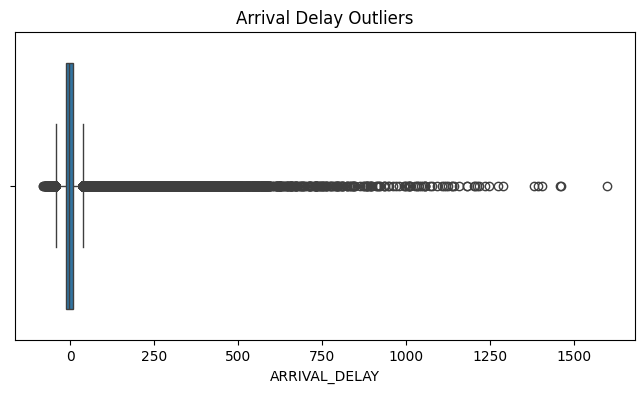

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['ARRIVAL_DELAY'])
plt.title("Arrival Delay Outliers")
plt.show()

In [ ]:
Q1 = df['ARRIVAL_DELAY'].quantile(0.25)
Q3 = df['ARRIVAL_DELAY'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].clip(lower,upper)

In [ ]:
Q1 = df['DEPARTURE_DELAY'].quantile(0.25)
Q3 = df['DEPARTURE_DELAY'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].clip(lower,upper)

In [ ]:
Q1 = df['DISTANCE'].quantile(0.25)
Q3 = df['DISTANCE'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['DISTANCE'] = df['DISTANCE'].clip(lower,upper)

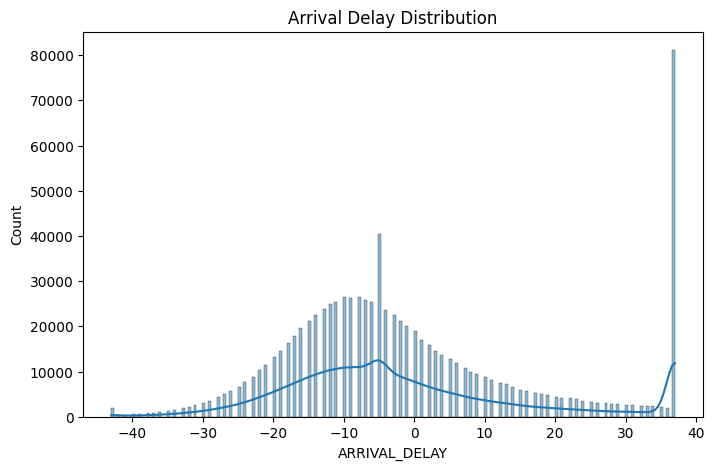

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[df['ARRIVAL_DELAY'] < 200]['ARRIVAL_DELAY'],
    kde=True
)

plt.title("Arrival Delay Distribution")
plt.show()

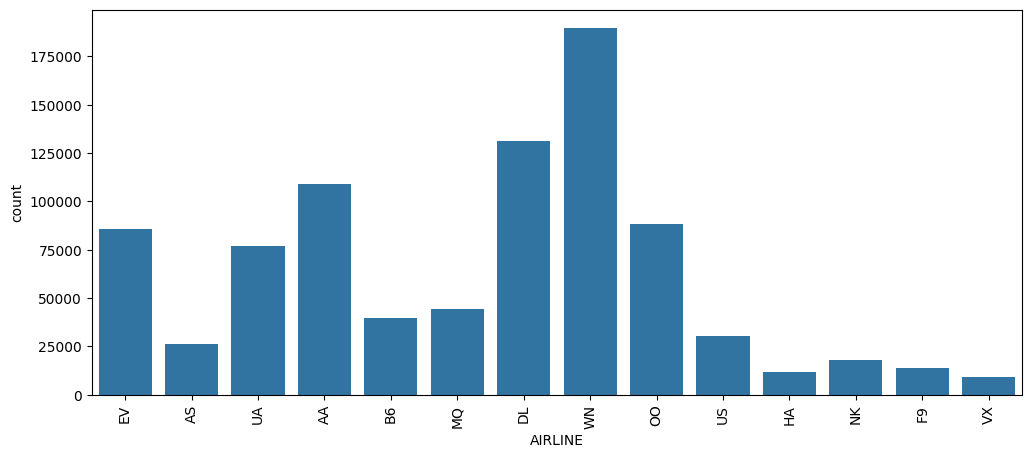

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(x='AIRLINE',data=df)

plt.xticks(rotation=90)

plt.show()

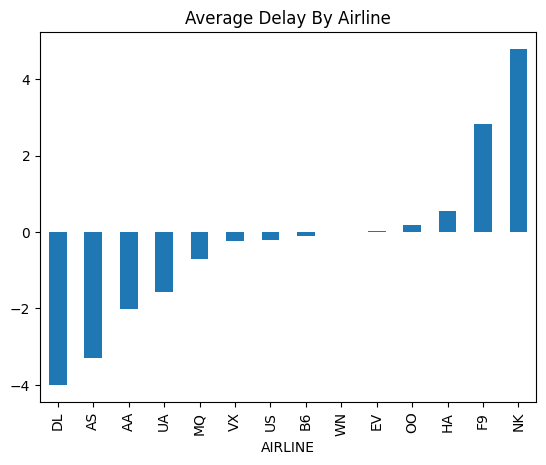

In [ ]:
avg_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean()

avg_delay.sort_values().plot(kind='bar')

plt.title("Average Delay By Airline")

plt.show()

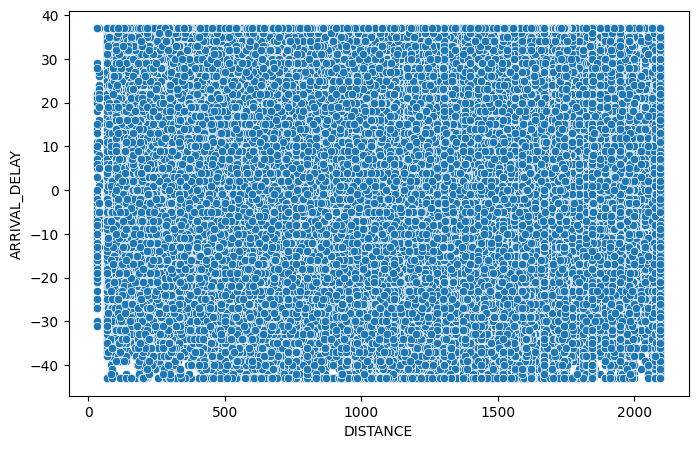

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='DISTANCE',
    y='ARRIVAL_DELAY',
    data=df
)

plt.show()

In [ ]:
df['DELAY_STATUS'] = np.where(df['ARRIVAL_DELAY'] > 15,1,0)

In [ ]:
df = df[[
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'DELAY_STATUS'
]]

In [ ]:
le = LabelEncoder()

df['AIRLINE'] = le.fit_transform(df['AIRLINE'])

df['ORIGIN_AIRPORT'] = le.fit_transform(df['ORIGIN_AIRPORT'])

df['DESTINATION_AIRPORT'] = le.fit_transform(df['DESTINATION_AIRPORT'])

/tmp/ipykernel_4758/3492425846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIRLINE'] = le.fit_transform(df['AIRLINE'])
/tmp/ipykernel_4758/3492425846.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ORIGIN_AIRPORT'] = le.fit_transform(df['ORIGIN_AIRPORT'])
/tmp/ipykernel_4758/3492425846.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

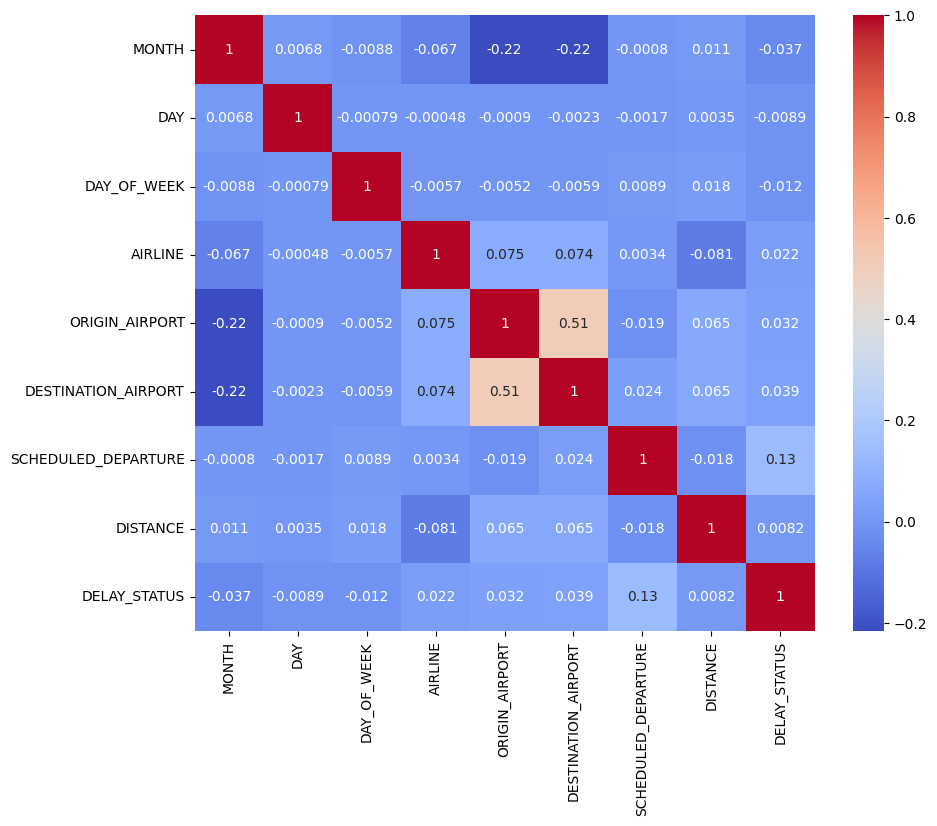

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
X = df.drop('DELAY_STATUS',axis=1)

y = df['DELAY_STATUS']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,pred)

print("Accuracy :",round(accuracy*100,2),"%")

Accuracy : 82.63 %


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.84      0.98      0.90    143890
           1       0.54      0.09      0.15     30683

    accuracy                           0.83    174573
   macro avg       0.69      0.54      0.53    174573
weighted avg       0.78      0.83      0.77    174573



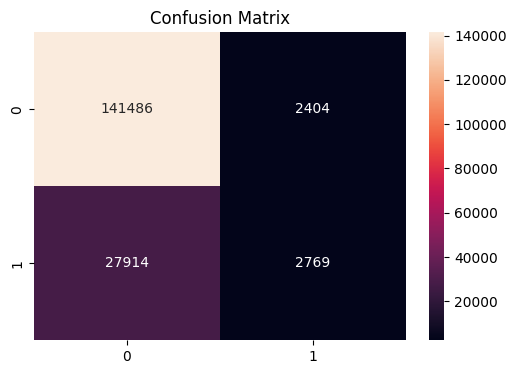

In [ ]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()